#Initialization

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Stunted Children Identification/stunting-identification-lab

Mounted at /content/drive
/content/drive/MyDrive/Stunted Children Identification/stunting-identification-lab


In [2]:
import pandas as pd
import numpy as np

In [3]:
data_info_file = "/content/drive/MyDrive/Stunted Children Identification/stunting-identification-lab/ref_based_aug_dataset_info.xlsx"
dataset_df = pd.read_excel(data_info_file)
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   child_id     7600 non-null   int64 
 1   cap_id       7600 non-null   int64 
 2   stage        7600 non-null   object
 3   variant      7600 non-null   object
 4   cap_kind     7600 non-null   object
 5   label        7600 non-null   int64 
 6   source_path  7600 non-null   object
 7   path         7600 non-null   object
dtypes: int64(3), object(5)
memory usage: 475.1+ KB


#Sample Figure

In [ ]:
import matplotlib.pyplot as plt
import math
import cv2

In [ ]:
pre_processed_samples_df = dataset_df[(dataset_df.child_id == 189)]
print('number of samples: ', len(pre_processed_samples_df))

number of samples:  40


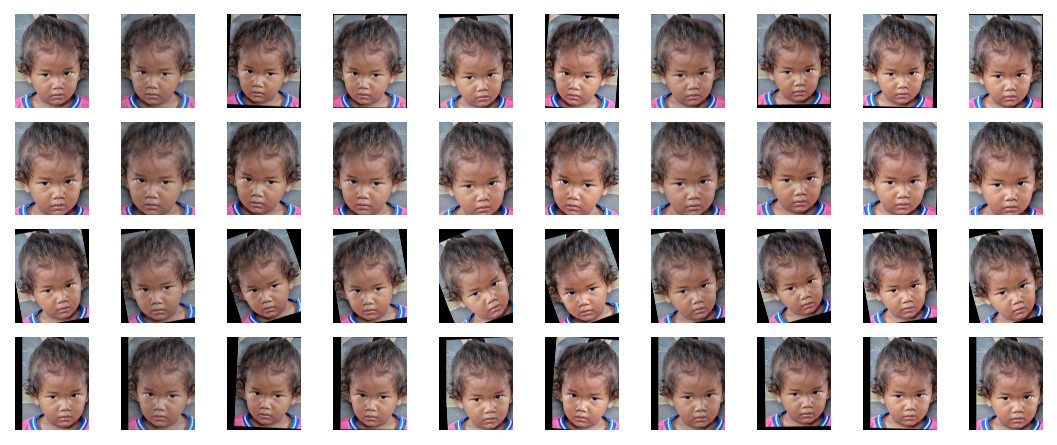

In [ ]:
n    = len(pre_processed_samples_df)
cols = 10
rows = math.ceil(n / cols)

cell = 0.9
fig  = plt.figure(figsize=(cell*cols, cell*rows), dpi=150)

for i in range(n):
  idx = 4*(i%10)+((i-(i%10))%9)
  path = pre_processed_samples_df.path.iloc[idx]
  img  = cv2.imread(path)
  img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  ax = fig.add_subplot(rows, cols, i + 1)
  ax.imshow(img)
  ax.axis("off")
  #ax.set_title(str(idx), fontsize=6, pad=1)

plt.subplots_adjust(wspace=0.15, hspace=0.15)
plt.show()

#Raw Dataset

In [4]:
raw_dataset_df = pd.read_excel("/content/drive/MyDrive/Stunted Children Identification/stunting-identification-lab/dataset_info.xlsx")
display(raw_dataset_df.info())
display(raw_dataset_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   child_id       190 non-null    int64 
 1   state          190 non-null    object
 2   cap_kind       190 non-null    object
 3   label          190 non-null    int64 
 4   health_center  190 non-null    object
 5   path           190 non-null    object
dtypes: int64(2), object(4)
memory usage: 9.0+ KB


None

,child_id,state,cap_kind,label,health_center,path
0,0,Stunting,original,1,health center 1,/content/drive/MyDrive/Stunted Children Identi...
1,1,Severe stunting,original,1,health center 1,/content/drive/MyDrive/Stunted Children Identi...
2,2,Stunting,original,1,health center 1,/content/drive/MyDrive/Stunted Children Identi...
3,3,Stunting,original,1,health center 1,/content/drive/MyDrive/Stunted Children Identi...
4,4,Severe stunting,original,1,health center 1,/content/drive/MyDrive/Stunted Children Identi...


#Balanced Dataset

In [10]:
SEED = 123

In [ ]:
# Subset Function

def subset_data(data, n, seed):
    # Split by class
    df = data.copy()
    df_stunted = df[df["label"] == 1]
    df_normal  = df[df["label"] == 0]

    assert len(df_stunted) >= n, f"Not enough stunted: {len(df_stunted)}"
    assert len(df_normal)  >= n, f"Not enough normal: {len(df_normal)}"

    df_subset_stunted = df_stunted.sample(n=50, random_state=seed)
    df_subset_normal  = df_normal.sample(n=50, random_state=seed)

    df_subset = pd.concat([df_subset_stunted, df_subset_normal], ignore_index=True)
    df_subset = df_subset.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    return df_subset

In [ ]:
#balanced_samples_df = subset_data(raw_dataset_df, n=50, seed=SEED)
#display(balanced_samples_df.info())
#display(balanced_samples_df)

#balanced_samples_df.to_excel('balanced_samples_info.xlsx', index=False)

In [ ]:
balanced_samples_df = pd.read_excel("balanced_samples_info.xlsx")
balanced_samples_df.head()

,child_id,state,cap_kind,label,health_center,path
0,181,Severe stunting,original,1,health center 2,/content/drive/MyDrive/Stunted Children Identi...
1,139,Normal,original,0,health center 3,/content/drive/MyDrive/Stunted Children Identi...
2,157,Normal,original,0,health center 2,/content/drive/MyDrive/Stunted Children Identi...
3,50,Stunting,original,1,health center 1,/content/drive/MyDrive/Stunted Children Identi...
4,110,Normal,original,0,health center 3,/content/drive/MyDrive/Stunted Children Identi...


In [ ]:
balanced_dataset_df = dataset_df[dataset_df.child_id.isin(balanced_samples_df.child_id)]
balanced_dataset_df[["child_id", "cap_id", "stage", "variant", "cap_kind", "label"]].head()

,child_id,cap_id,stage,variant,cap_kind,label
0,0,0,capture,base_capture,original,1
1,0,0,ref_augmentation,zoom_in,original-augmentation,1
2,0,0,ref_augmentation,rotation,original-augmentation,1
3,0,0,ref_augmentation,shift_right,original-augmentation,1
4,0,1,capture,base_capture,original-pseudo,1


In [ ]:
balanced_dataset_df.cap_kind.unique()

array(['original', 'original-augmentation', 'original-pseudo',
       'original-pseudo-augmentation'], dtype=object)

In [ ]:
#Balanced Dataset
#original                    :  100 original images
#original-augmentation       : (100 original images x 3 ref.-based augmentation) = 300
#original-pseudo             :  100 original images x 9 pseudo capture = 900
#original-pseudo-augmentation: (100 original images x 9 pseudo captures) x 3 ref.-based augmentation = 2700

In [ ]:
balanced_dataset_df.groupby("cap_kind")["child_id"].count()

,child_id
cap_kind,
original,100
original-augmentation,300
original-pseudo,900
original-pseudo-augmentation,2700


#Split Data

In [12]:
import hashlib

from sklearn.model_selection import train_test_split

In [ ]:
# Image Level Split

def image_level_split(df, val_ratio=0.10, test_ratio=0.10, seed=123):
    # first split off test
    trainval, test = train_test_split(
        df, test_size=test_ratio, random_state=seed, stratify=df["label"]
    )
    # split train/val from remaining
    val_frac_of_trainval = val_ratio / (1.0 - test_ratio)
    train, val = train_test_split(
        trainval, test_size=val_frac_of_trainval, random_state=seed, stratify=trainval["label"]
    )
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

In [6]:
# Conventional Imbalance Split (Stratified Split)

def stratified_subject_disjoint_split(df, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, seed=123,
                                      train_cap=['original'],
                                      val_test_cap=['original']):

    df["child_id"] = df["child_id"].astype(str)
    df["label"]    = df["label"].astype(int)

    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("train_ratio + val_ratio + test_ratio must equal 1.")

    child_tbl = (
        df.groupby("child_id")["label"]
          .agg(lambda s: int(pd.Series.mode(s).iloc[0]))
          .reset_index()
          .rename(columns={"label": "child_label"})
    )

    rng = np.random.default_rng(seed)
    train_ids, val_ids, test_ids = [], [], []

    for lab in sorted(child_tbl["child_label"].unique()):
        kids = child_tbl.loc[child_tbl["child_label"] == lab, "child_id"].astype(str).to_numpy()
        rng.shuffle(kids)
        n = len(kids)

        n_test = max(1, int(round(test_ratio * n)))
        n_val  = max(1, int(round(val_ratio * n)))

        if n_test + n_val >= n:
            # keep at least one subject in train
            n_test = max(1, n_test - 1)
            if n_test + n_val >= n:
                n_val = max(1, n_val - 1)

        test_ids.extend(kids[:n_test].tolist())
        val_ids.extend(kids[n_test:n_test+n_val].tolist())
        train_ids.extend(kids[n_test+n_val:].tolist())

    train_df = df[df["child_id"].isin(train_ids) & df["cap_kind"].isin(train_cap)].reset_index(drop=True)
    val_df   = df[df["child_id"].isin(val_ids) & df["cap_kind"].isin(val_test_cap)].reset_index(drop=True)
    test_df  = df[df["child_id"].isin(test_ids) & df["cap_kind"].isin(val_test_cap)].reset_index(drop=True)

    tr = set(train_df["child_id"]); va = set(val_df["child_id"]); te = set(test_df["child_id"])
    assert tr.isdisjoint(va) and tr.isdisjoint(te) and va.isdisjoint(te), "Leakage detected in child_id split."

    return train_df, val_df, test_df


In [7]:
# Split Summarize Data

def split_hash(ids):
    txt = "\n".join(sorted(map(str, ids)))
    return hashlib.sha256(txt.encode("utf-8")).hexdigest()

def summarize_split(df, name):
    child_labels = (
        df.groupby("child_id")["label"]
          .agg(lambda s: int(pd.Series.mode(s).iloc[0]))
          .value_counts()
          .sort_index()
          .to_dict()
    )
    label_counts = df["label"].value_counts().sort_index().to_dict()
    return {
        "split": name,
        "n_images": int(len(df)),
        "n_children": int(df["child_id"].nunique()),
        "child_label_0": int(child_labels.get(0, 0)),
        "child_label_1": int(child_labels.get(1, 0)),
        "image_label_0": int(label_counts.get(0, 0)),
        "image_label_1": int(label_counts.get(1, 0)),
        "child_id_hash": split_hash(df["child_id"].unique().tolist()),
    }

In [8]:
# Split Data Configuration
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

base = "/content/drive/MyDrive/Stunted Children Identification/stunting-identification-lab/train-val-test/"

#Scheme 1.a. Dataset

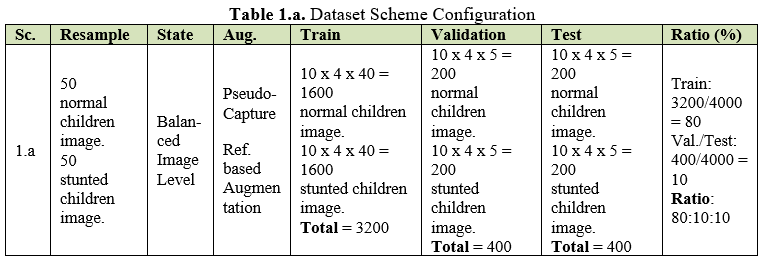

In [ ]:
# Scheme 1.a.:

# Balance dataset -> subset_data() -> balanced dataset_df
# Sbj. Disjoint ->  image_level_split()
# Train -> ['original', 'original-augmentation', 'original-pseudo', 'original-pseudo-augmentation']
# val_test_cap -> ['original', 'original-augmentation', 'original-pseudo', 'original-pseudo-augmentation']

train_sc1a_df, val_sc1a_df, test_sc1a_df = image_level_split(
        balanced_dataset_df,
        val_ratio=VAL_RATIO,
        test_ratio=TEST_RATIO,
        seed=SEED
    )

split_summary = pd.DataFrame([
    summarize_split(train_sc1a_df, "train"),
    summarize_split(val_sc1a_df, "val"),
    summarize_split(test_sc1a_df, "test"),
])

print("=== SUBJECT-DISJOINT SPLIT SUMMARY ===")
display(split_summary)

train_sc1a_df.to_excel(base + 'sc1a/train_sc1a.xlsx', index=False)
val_sc1a_df.to_excel(base + 'sc1a/val_sc1a.xlsx', index=False)
test_sc1a_df.to_excel(base + 'sc1a/test_sc1a.xlsx', index=False)

=== SUBJECT-DISJOINT SPLIT SUMMARY ===


,split,n_images,n_children,child_label_0,child_label_1,image_label_0,image_label_1,child_id_hash
0,train,3200,100,50,50,1600,1600,5bce1120f53eb4555e4b1067c07dcba2d8247b96ca7ed3...
1,val,400,99,49,50,200,200,a67fb44e5c1aa09283d43c582d91d5b180cde32d2bd9ad...
2,test,400,100,50,50,200,200,5bce1120f53eb4555e4b1067c07dcba2d8247b96ca7ed3...


In [ ]:
tr = set(train_sc1a_df["child_id"]); va = set(val_sc1a_df["child_id"]); te = set(test_sc1a_df["child_id"])
if not(tr.isdisjoint(va) and tr.isdisjoint(te) and va.isdisjoint(te)):
    print("Leakage detected in child_id split.")
else:
  print("Leakage not detected in child_id split.")

Leakage detected in child_id split.


In [ ]:
train_child_id = set(train_sc1a_df["child_id"].unique())
val_child_id   = set(val_sc1a_df["child_id"].unique())
test_child_id  = set(test_sc1a_df["child_id"].unique())

print("number of child in train: ", len(train_child_id))
print("number of child in val: ", len(val_child_id))
print("number of child in test: ", len(test_child_id))
print("percentage of intersection between train child id and val child id is ",
      len(train_child_id.intersection(val_child_id)) / len(train_child_id) * 100)
print("percentage of intersection between train child id and test child id is ",
      len(train_child_id.intersection(test_child_id)) / len(train_child_id) * 100)


number of child in train:  100
number of child in val:  99
number of child in test:  100
percentage of intersection between train child id and val child id is  99.0
percentage of intersection between train child id and test child id is  100.0


In [ ]:
print("sample of train child id: ", np.array(list(train_child_id))[:10])
print("sample of val child id: ", np.array(list(val_child_id))[:10])
print("sample of test child id: ", np.array(list(test_child_id))[:10])

sample of train child id:  [ 0  1  3  4  5  6  9 10 11 13]
sample of val child id:  [ 0  1  3  4  5  6  9 10 11 13]
sample of test child id:  [ 0  1  3  4  5  6  9 10 11 13]


#Scheme 1.b. Dataset

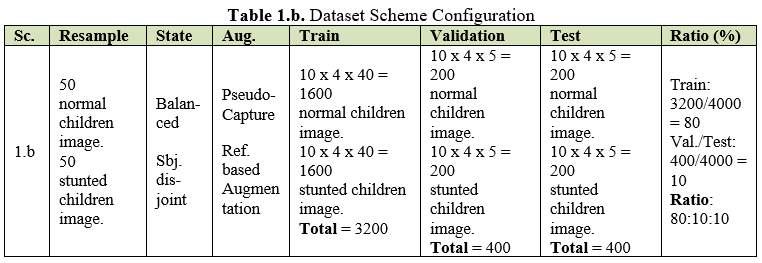

In [ ]:
# Scheme 1.b.:

# Balance dataset -> subset_data() -> balanced dataset_df
# Sbj. Disjoint -> stratified_subject_disjoint_split()
# Train -> ['original', 'original-augmentation', 'original-pseudo', 'original-pseudo-augmentation']
# val_test_cap -> ['original', 'original-augmentation', 'original-pseudo', 'original-pseudo-augmentation']

train_sc1b_df, val_sc1b_df, test_sc1b_df = stratified_subject_disjoint_split(
    balanced_dataset_df,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
    train_cap=['original', 'original-augmentation', 'original-pseudo', 'original-pseudo-augmentation'],
    val_test_cap=['original', 'original-augmentation', 'original-pseudo', 'original-pseudo-augmentation'],
    )

split_summary = pd.DataFrame([
    summarize_split(train_sc1b_df, "train"),
    summarize_split(val_sc1b_df, "val"),
    summarize_split(test_sc1b_df, "test"),
])

print("=== SUBJECT-DISJOINT SPLIT SUMMARY ===")
display(split_summary)

train_sc1b_df.to_excel(base + 'sc1b/train_sc1b.xlsx', index=False)
val_sc1b_df.to_excel(base + 'sc1b/val_sc1b.xlsx', index=False)
test_sc1b_df.to_excel(base + 'sc1b/test_sc1b.xlsx', index=False)

=== SUBJECT-DISJOINT SPLIT SUMMARY ===


/tmp/ipykernel_7781/3947572474.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["child_id"] = df["child_id"].astype(str)
/tmp/ipykernel_7781/3947572474.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"]    = df["label"].astype(int)


,split,n_images,n_children,child_label_0,child_label_1,image_label_0,image_label_1,child_id_hash
0,train,3200,80,40,40,1600,1600,49248d19a34023274ae15914ec7af9596420d0f1ea6e93...
1,val,400,10,5,5,200,200,da6a3852996847249e8683d7e8da91f95d1d0b9202deb4...
2,test,400,10,5,5,200,200,f1758be9eb73911dda9c7df7a10385f0da6be71d0b0b47...


In [ ]:
tr = set(train_sc1b_df["child_id"]); va = set(val_sc1b_df["child_id"]); te = set(test_sc1b_df["child_id"])
if not(tr.isdisjoint(va) and tr.isdisjoint(te) and va.isdisjoint(te)):
  print("Leakage detected in child_id split.")
else:
  print("Leakage not detected in child_id split.")

Leakage not detected in child_id split.


In [ ]:
train_child_id = train_sc1b_df["child_id"].unique()
val_child_id   = val_sc1b_df["child_id"].unique()
test_child_id  = test_sc1b_df["child_id"].unique()

print("sample of train child id: ", train_child_id[:10])
print("sample of val child id: ", val_child_id[:10])
print("sample of test child id: ", test_child_id[:10])


sample of train child id:  ['0' '3' '4' '5' '9' '10' '13' '14' '18' '20']
sample of val child id:  ['1' '11' '15' '30' '69' '107' '162' '170' '177' '178']
sample of test child id:  ['6' '16' '54' '56' '61' '129' '141' '150' '152' '153']


#Scheme 2.a. Dataset

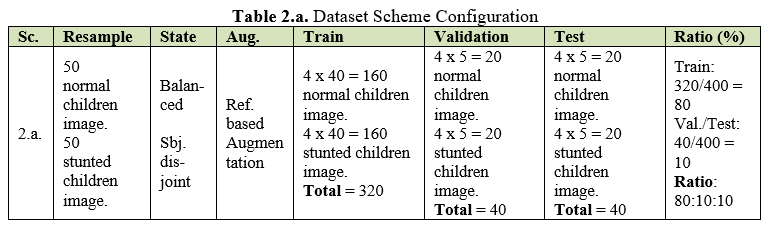

In [ ]:
# Scheme 2.a.:

# Balance dataset -> subset_data() -> balanced dataset_df
# Sbj. Disjoint -> stratified_subject_disjoint_split()
# Train -> ['original', 'original-augmentation']
# val_test_cap -> ['original', 'original-augmentation']

train_sc2a_df, val_sc2a_df, test_sc2a_df = stratified_subject_disjoint_split(
    balanced_dataset_df,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
    train_cap=['original', 'original-augmentation'],
    val_test_cap=['original', 'original-augmentation']
    )

split_summary = pd.DataFrame([
    summarize_split(train_sc2a_df, "train"),
    summarize_split(val_sc2a_df, "val"),
    summarize_split(test_sc2a_df, "test"),
])

print("=== SUBJECT-DISJOINT SPLIT SUMMARY ===")
display(split_summary)

train_sc2a_df.to_excel(base + 'sc2a/train_sc2a.xlsx', index=False)
val_sc2a_df.to_excel(base + 'sc2a/val_sc2a.xlsx', index=False)
test_sc2a_df.to_excel(base + 'sc2a/test_sc2a.xlsx', index=False)

=== SUBJECT-DISJOINT SPLIT SUMMARY ===


/tmp/ipykernel_7781/3947572474.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["child_id"] = df["child_id"].astype(str)
/tmp/ipykernel_7781/3947572474.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"]    = df["label"].astype(int)


,split,n_images,n_children,child_label_0,child_label_1,image_label_0,image_label_1,child_id_hash
0,train,320,80,40,40,160,160,49248d19a34023274ae15914ec7af9596420d0f1ea6e93...
1,val,40,10,5,5,20,20,da6a3852996847249e8683d7e8da91f95d1d0b9202deb4...
2,test,40,10,5,5,20,20,f1758be9eb73911dda9c7df7a10385f0da6be71d0b0b47...


In [ ]:
tr = set(train_sc2a_df["child_id"]); va = set(val_sc2a_df["child_id"]); te = set(test_sc2a_df["child_id"])
if not(tr.isdisjoint(va) and tr.isdisjoint(te) and va.isdisjoint(te)):
  print("Leakage detected in child_id split.")
else:
  print("Leakage not detected in child_id split.")

Leakage not detected in child_id split.


In [ ]:
train_child_id = train_sc2a_df["child_id"].unique()
val_child_id   = val_sc2a_df["child_id"].unique()
test_child_id  = test_sc2a_df["child_id"].unique()

print("sample of train child id: ", train_child_id[:10])
print("sample of val child id: ", val_child_id[:10])
print("sample of test child id: ", test_child_id[:10])


sample of train child id:  ['0' '3' '4' '5' '9' '10' '13' '14' '18' '20']
sample of val child id:  ['1' '11' '15' '30' '69' '107' '162' '170' '177' '178']
sample of test child id:  ['6' '16' '54' '56' '61' '129' '141' '150' '152' '153']


#Scheme 2.b. Dataset

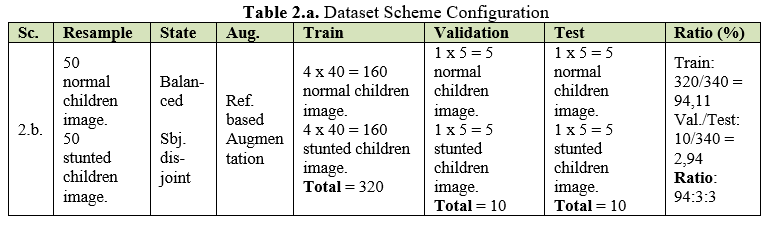

In [ ]:
# Scheme 2.b.:

# Balance dataset -> subset_data() -> balanced dataset_df
# Sbj. Disjoint -> stratified_subject_disjoint_split()
# Train -> ['original', 'original-augmentation']
# val_test_cap -> ['original']

train_sc2b_df, val_sc2b_df, test_sc2b_df = stratified_subject_disjoint_split(
    balanced_dataset_df,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
    train_cap=['original', 'original-augmentation'],
    val_test_cap=['original']
    )

split_summary = pd.DataFrame([
    summarize_split(train_sc2b_df, "train"),
    summarize_split(val_sc2b_df, "val"),
    summarize_split(test_sc2b_df, "test"),
])

print("=== SUBJECT-DISJOINT SPLIT SUMMARY ===")
display(split_summary)

train_sc2b_df.to_excel(base + 'sc2b/train_sc2b.xlsx', index=False)
val_sc2b_df.to_excel(base + 'sc2b/val_sc2b.xlsx', index=False)
test_sc2b_df.to_excel(base + 'sc2b/test_sc2b.xlsx', index=False)

=== SUBJECT-DISJOINT SPLIT SUMMARY ===


/tmp/ipykernel_7781/3947572474.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["child_id"] = df["child_id"].astype(str)
/tmp/ipykernel_7781/3947572474.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"]    = df["label"].astype(int)


,split,n_images,n_children,child_label_0,child_label_1,image_label_0,image_label_1,child_id_hash
0,train,320,80,40,40,160,160,49248d19a34023274ae15914ec7af9596420d0f1ea6e93...
1,val,10,10,5,5,5,5,da6a3852996847249e8683d7e8da91f95d1d0b9202deb4...
2,test,10,10,5,5,5,5,f1758be9eb73911dda9c7df7a10385f0da6be71d0b0b47...


In [ ]:
tr = set(train_sc2b_df["child_id"]); va = set(val_sc2b_df["child_id"]); te = set(test_sc2b_df["child_id"])
if not(tr.isdisjoint(va) and tr.isdisjoint(te) and va.isdisjoint(te)):
  print("Leakage detected in child_id split.")
else:
  print("Leakage not detected in child_id split.")

Leakage not detected in child_id split.


In [ ]:
train_child_id = train_sc2b_df["child_id"].unique()
val_child_id   = val_sc2b_df["child_id"].unique()
test_child_id  = test_sc2b_df["child_id"].unique()

print("sample of train child id: ", train_child_id[:10])
print("sample of val child id: ", val_child_id[:10])
print("sample of test child id: ", test_child_id[:10])


sample of train child id:  ['0' '3' '4' '5' '9' '10' '13' '14' '18' '20']
sample of val child id:  ['1' '11' '15' '30' '69' '107' '162' '170' '177' '178']
sample of test child id:  ['6' '16' '54' '56' '61' '129' '141' '150' '152' '153']


#Scheme 3 Dataset

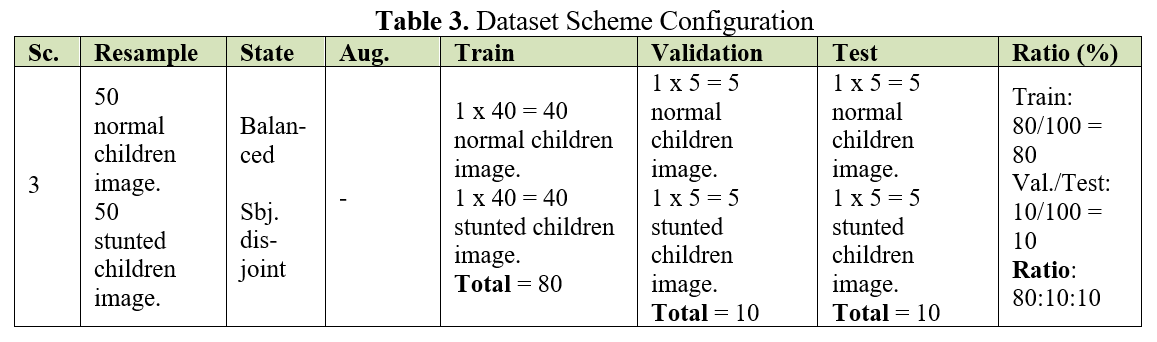

In [ ]:
# Scheme 3:

# Balance dataset -> subset_data() -> balanced dataset_df
# Sbj. Disjoint -> stratified_subject_disjoint_split()
# Train -> ['original']
# val_test_cap -> ['original']

train_sc3_df, val_sc3_df, test_sc3_df = stratified_subject_disjoint_split(
    balanced_dataset_df,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
    train_cap=['original'],
    val_test_cap=['original']
    )

split_summary = pd.DataFrame([
    summarize_split(train_sc3_df, "train"),
    summarize_split(val_sc3_df, "val"),
    summarize_split(test_sc3_df, "test"),
])

print("=== SUBJECT-DISJOINT SPLIT SUMMARY ===")
display(split_summary)

train_sc3_df.to_excel(base + 'sc3/train_sc3.xlsx', index=False)
val_sc3_df.to_excel(base + 'sc3/val_sc3.xlsx', index=False)
test_sc3_df.to_excel(base + 'sc3/test_sc3.xlsx', index=False)

=== SUBJECT-DISJOINT SPLIT SUMMARY ===


/tmp/ipykernel_7781/3947572474.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["child_id"] = df["child_id"].astype(str)
/tmp/ipykernel_7781/3947572474.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"]    = df["label"].astype(int)


,split,n_images,n_children,child_label_0,child_label_1,image_label_0,image_label_1,child_id_hash
0,train,80,80,40,40,40,40,49248d19a34023274ae15914ec7af9596420d0f1ea6e93...
1,val,10,10,5,5,5,5,da6a3852996847249e8683d7e8da91f95d1d0b9202deb4...
2,test,10,10,5,5,5,5,f1758be9eb73911dda9c7df7a10385f0da6be71d0b0b47...


In [ ]:
tr = set(train_sc3_df["child_id"]); va = set(val_sc3_df["child_id"]); te = set(test_sc3_df["child_id"])
if not(tr.isdisjoint(va) and tr.isdisjoint(te) and va.isdisjoint(te)):
  print("Leakage detected in child_id split.")
else:
  print("Leakage not detected in child_id split.")

Leakage not detected in child_id split.


In [ ]:
train_child_id = train_sc3_df["child_id"].unique()
val_child_id   = val_sc3_df["child_id"].unique()
test_child_id  = test_sc3_df["child_id"].unique()

print("sample of train child id: ", train_child_id[:10])
print("sample of val child id: ", val_child_id[:10])
print("sample of test child id: ", test_child_id[:10])


sample of train child id:  ['0' '3' '4' '5' '9' '10' '13' '14' '18' '20']
sample of val child id:  ['1' '11' '15' '30' '69' '107' '162' '170' '177' '178']
sample of test child id:  ['6' '16' '54' '56' '61' '129' '141' '150' '152' '153']


#Scheme 4.a Dataset

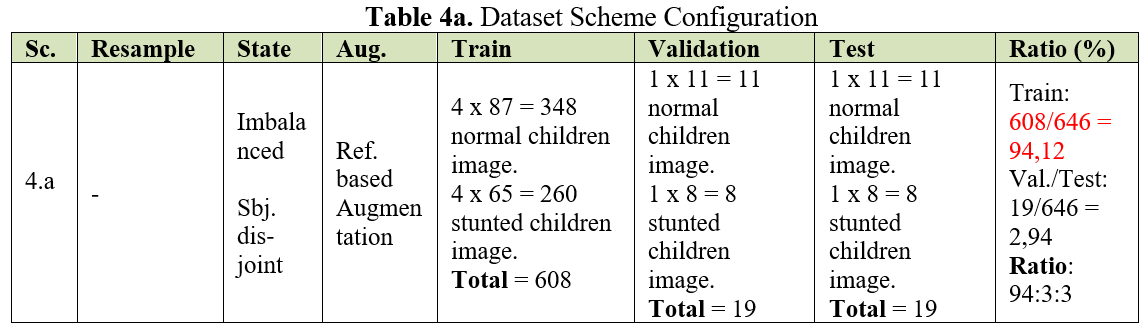

In [14]:
# Scheme 4.a:

# Imbalanced dataset -> dataset_df
# Sbj. Disjoint -> stratified_subject_disjoint_split()
# Train -> ['original', 'original-augmentation']
# val_test_cap -> ['original']

train_sc4a_df, val_sc4a_df, test_sc4a_df = stratified_subject_disjoint_split(
    dataset_df,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
    train_cap=['original', 'original-augmentation'],
    val_test_cap=['original']
    )

split_summary = pd.DataFrame([
    summarize_split(train_sc4a_df, "train"),
    summarize_split(val_sc4a_df, "val"),
    summarize_split(test_sc4a_df, "test"),
])

print("=== SUBJECT-DISJOINT SPLIT SUMMARY ===")
display(split_summary)

train_sc4a_df.to_excel(base + 'sc4a/train_sc4a.xlsx', index=False)
val_sc4a_df.to_excel(base + 'sc4a/val_sc4a.xlsx', index=False)
test_sc4a_df.to_excel(base + 'sc4a/test_sc4a.xlsx', index=False)

=== SUBJECT-DISJOINT SPLIT SUMMARY ===


,split,n_images,n_children,child_label_0,child_label_1,image_label_0,image_label_1,child_id_hash
0,train,608,152,87,65,348,260,a46c1e2ca3d617c864520c64b54fc0588ef19443b58d73...
1,val,19,19,11,8,11,8,b9a899f7e24d35271320afb8597341f7f2cbe423123d27...
2,test,19,19,11,8,11,8,f6ee7aacbebc6698830d839595850eac659eacf5e20fe7...


In [15]:
tr = set(train_sc4a_df["child_id"]); va = set(val_sc4a_df["child_id"]); te = set(test_sc4a_df["child_id"])
if not(tr.isdisjoint(va) and tr.isdisjoint(te) and va.isdisjoint(te)):
  print("Leakage detected in child_id split.")
else:
  print("Leakage not detected in child_id split.")

Leakage not detected in child_id split.


In [16]:
train_child_id = train_sc4a_df["child_id"].unique()
val_child_id   = val_sc4a_df["child_id"].unique()
test_child_id  = test_sc4a_df["child_id"].unique()

print("sample of train child id: ", train_child_id[:10])
print("sample of val child id: ", val_child_id[:10])
print("sample of test child id: ", test_child_id[:10])


sample of train child id:  ['0' '1' '2' '3' '5' '6' '7' '8' '9' '10']
sample of val child id:  ['4' '13' '24' '28' '37' '77' '93' '116' '125' '128']
sample of test child id:  ['15' '18' '29' '43' '48' '50' '55' '56' '68' '78']


#Scheme 4.b. Dataset

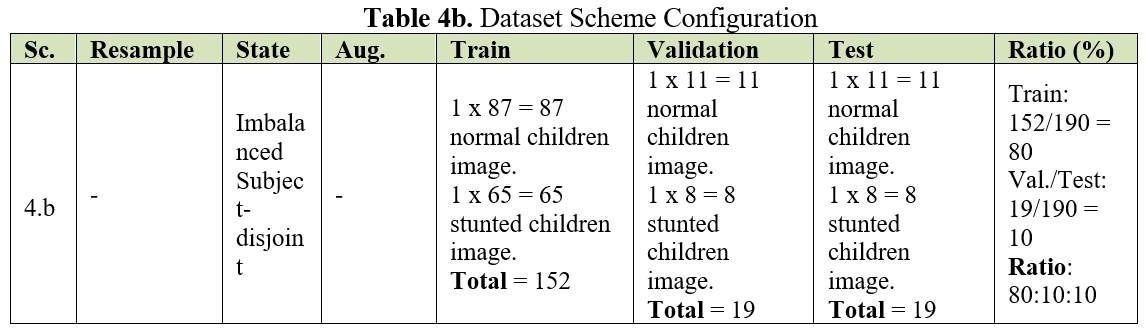

In [17]:
# Scheme 4.b:

# Imbalanced dataset -> dataset_df
# Sbj. Disjoint -> stratified_subject_disjoint_split()
# Train -> ['original']
# val_test_cap -> ['original']

train_sc4b_df, val_sc4b_df, test_sc4b_df = stratified_subject_disjoint_split(
    dataset_df,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
    train_cap=['original'],
    val_test_cap=['original']
    )

split_summary = pd.DataFrame([
    summarize_split(train_sc4b_df, "train"),
    summarize_split(val_sc4b_df, "val"),
    summarize_split(test_sc4b_df, "test"),
])

print("=== SUBJECT-DISJOINT SPLIT SUMMARY ===")
display(split_summary)

train_sc4b_df.to_excel(base + 'sc4b/train_sc4b.xlsx', index=False)
val_sc4b_df.to_excel(base + 'sc4b/val_sc4b.xlsx', index=False)
test_sc4b_df.to_excel(base + 'sc4b/test_sc4b.xlsx', index=False)

=== SUBJECT-DISJOINT SPLIT SUMMARY ===


,split,n_images,n_children,child_label_0,child_label_1,image_label_0,image_label_1,child_id_hash
0,train,152,152,87,65,87,65,a46c1e2ca3d617c864520c64b54fc0588ef19443b58d73...
1,val,19,19,11,8,11,8,b9a899f7e24d35271320afb8597341f7f2cbe423123d27...
2,test,19,19,11,8,11,8,f6ee7aacbebc6698830d839595850eac659eacf5e20fe7...


In [18]:
tr = set(train_sc4b_df["child_id"]); va = set(val_sc4b_df["child_id"]); te = set(test_sc4b_df["child_id"])
if not(tr.isdisjoint(va) and tr.isdisjoint(te) and va.isdisjoint(te)):
  print("Leakage detected in child_id split.")
else:
  print("Leakage not detected in child_id split.")

Leakage not detected in child_id split.


In [19]:
train_child_id = train_sc4b_df["child_id"].unique()
val_child_id   = val_sc4b_df["child_id"].unique()
test_child_id  = test_sc4b_df["child_id"].unique()

print("sample of train child id: ", train_child_id[:10])
print("sample of val child id: ", val_child_id[:10])
print("sample of test child id: ", test_child_id[:10])


sample of train child id:  ['0' '1' '2' '3' '5' '6' '7' '8' '9' '10']
sample of val child id:  ['4' '13' '24' '28' '37' '77' '93' '116' '125' '128']
sample of test child id:  ['15' '18' '29' '43' '48' '50' '55' '56' '68' '78']
